In [49]:
# !pip install -U ultralytics

In [50]:
import ultralytics
print(f"Ultralytics version: {ultralytics.__version__}")
import torch
print(f"Torch version: {torch.__version__}")
import cv2
import numpy as np
from ultralytics import YOLO
import os
from PIL import Image
from torchvision import transforms
from IPython.display import display, clear_output 
from collections import defaultdict

import cv2
import numpy as np
from collections import defaultdict
from PIL import Image
from IPython.display import display, clear_output

Ultralytics version: 8.4.32
Torch version: 2.5.1


In [51]:

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

device = "cuda" if torch.cuda.is_available() else "cpu"
x = torch.rand(10000,10000).to(device)
print(x.device)

2.5.1
12.4
True
NVIDIA GeForce RTX 3070
cuda:0


In [52]:
!nvidia-smi

Tue Mar 31 00:21:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.71                 Driver Version: 595.71         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3070      WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   47C    P8             24W /  220W |    3794MiB /   8192MiB |     52%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

data\traffic.mp4
Detection_dev\model_training\yolo8_v0\main (1).ipynb

In [59]:
model = YOLO('yolov8n.pt')
video_path = r"../../../data/traffic.mp4"
start_time = 10  
end_time = 17   
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise IOError(f"Cant open {video_path}")

fps = cap.get(cv2.CAP_PROP_FPS)
if fps <= 0:
    raise ValueError("Invalid frame rate in video file.")

start_frame = int(start_time * fps)
end_frame = int(end_time * fps)
cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

True

In [60]:
cap = cv2.VideoCapture(video_path)

In [61]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
class Car:
    def __init__(self, trackId: int):
        self.trackId = trackId
        self.x = 0.0
        self.y = 0.0
        self.w = 0.0
        self.h = 0.0
        self.maxConfidence = 0.0
        self.last_confidence = 0.0
        self.label = ""
        self.history = []
        self.lastCrop = None
        self.last_seen = -1
        self.updateCount = 0
        self.type = "unknown"
        self.Deaccelaration = self.getDeceleration()
        self.speed = 0.0
        self.breakingDistance = self.calcBreakingDistance()

    def calcBreakingDistance(self):
        # Placeholder logic for calculating breaking distance
        pass


    def  getDeceleration(self):
        type = self.type
        array = {
            "sedan": 3.0,
            "category2": 2.0,
            "bus": 2.5,
            "motorcycle": 4.0,
            "van": 2.5,
            "unknown": 2.0}
    
        return array.get(type, 2.0)
    

    def checkType(self):
        # Placeholder classification logic
        return "sedan"

    def update(self, box: tuple, confidence: float, label: str, frame: np.ndarray, frame_index: int) -> None:
        self.updateCount += 1
        self.x, self.y, self.w, self.h = box
        self.label = label
        self.last_confidence = confidence
        self.last_seen = frame_index
        self.history.append((float(self.x), float(self.y + self.h / 2)))

        if confidence > self.maxConfidence:
            self.maxConfidence = confidence

            x1 = int(self.x - self.w / 2)
            y1 = int(self.y - self.h / 2)
            x2 = int(self.x + self.w / 2)
            y2 = int(self.y + self.h / 2)

            crop = frame[max(0, y1):min(frame.shape[0], y2), max(0, x1):min(frame.shape[1], x2)]
            if crop.size > 0:
                self.lastCrop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
                self.type = self.checkType()


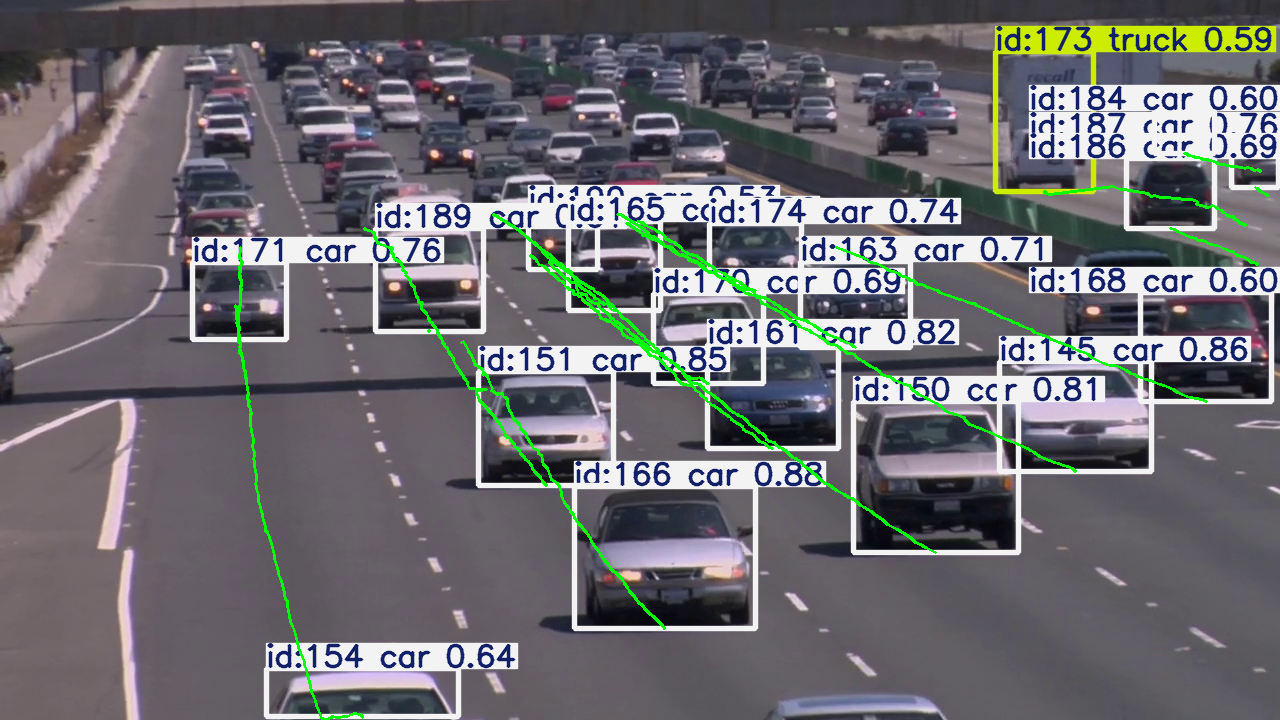

Car ID: 102 | Label: car | Conf: 0.90


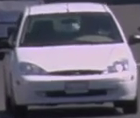

Car ID: 111 | Label: car | Conf: 0.91


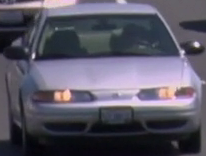

Car ID: 119 | Label: car | Conf: 0.92


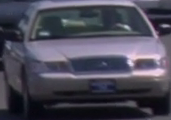

Car ID: 120 | Label: car | Conf: 0.93


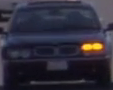

Car ID: 122 | Label: car | Conf: 0.88


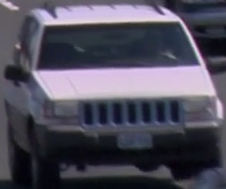

Car ID: 126 | Label: car | Conf: 0.81


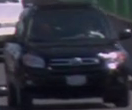

Car ID: 127 | Label: car | Conf: 0.90


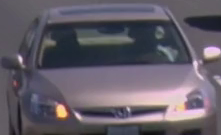

Car ID: 129 | Label: car | Conf: 0.87


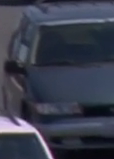

Car ID: 134 | Label: car | Conf: 0.91


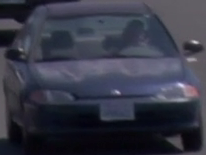

Car ID: 139 | Label: car | Conf: 0.79


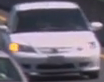

Car ID: 142 | Label: car | Conf: 0.91


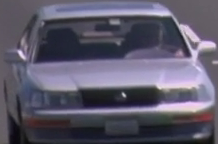

Car ID: 144 | Label: car | Conf: 0.88


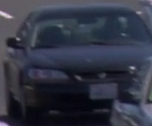

Car ID: 145 | Label: car | Conf: 0.89


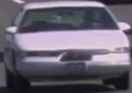

Car ID: 150 | Label: car | Conf: 0.84


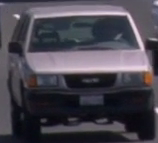

Car ID: 151 | Label: car | Conf: 0.88


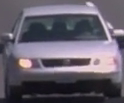

Car ID: 154 | Label: car | Conf: 0.91


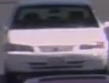

Car ID: 156 | Label: car | Conf: 0.88


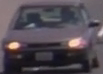

Car ID: 161 | Label: car | Conf: 0.87


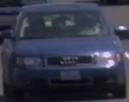

Car ID: 163 | Label: car | Conf: 0.81


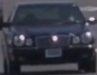

Car ID: 164 | Label: car | Conf: 0.72


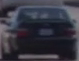

Car ID: 165 | Label: car | Conf: 0.71


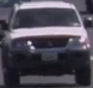

Car ID: 166 | Label: car | Conf: 0.89


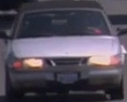

Car ID: 168 | Label: car | Conf: 0.82


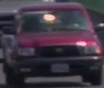

Car ID: 169 | Label: car | Conf: 0.85


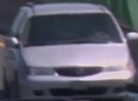

Car ID: 170 | Label: car | Conf: 0.77


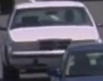

Car ID: 171 | Label: car | Conf: 0.86


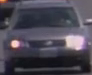

Car ID: 172 | Label: car | Conf: 0.66


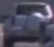

Car ID: 173 | Label: truck | Conf: 0.86


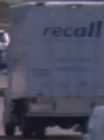

Car ID: 174 | Label: car | Conf: 0.80


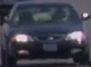

Car ID: 178 | Label: car | Conf: 0.82


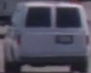

Car ID: 179 | Label: car | Conf: 0.60


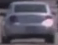

Car ID: 180 | Label: car | Conf: 0.80


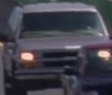

Car ID: 182 | Label: car | Conf: 0.59


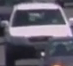

Car ID: 184 | Label: car | Conf: 0.77


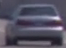

Car ID: 185 | Label: car | Conf: 0.56


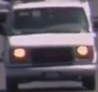

Car ID: 186 | Label: car | Conf: 0.84


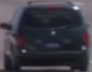

Car ID: 187 | Label: car | Conf: 0.77


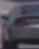

Car ID: 189 | Label: car | Conf: 0.64


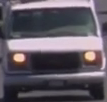

Car ID: 190 | Label: car | Conf: 0.53


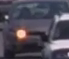

In [63]:
import cv2
import numpy as np
from collections import defaultdict
from PIL import Image
from IPython.display import display, clear_output

CONF_THRESHOLD = 0.5
OUTPUT_PATH = 'trajectory.mp4'
VIDEO_FOURCC = 'mp4v'
TRACK_COLOR = (0, 255, 0)
LINE_THICKNESS = 2
MAX_MISSING_FRAMES = 100

frameWidth = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frameHeight = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

fourcc = cv2.VideoWriter_fourcc(*VIDEO_FOURCC)
out = cv2.VideoWriter(OUTPUT_PATH, fourcc, fps, (frameWidth, frameHeight))

carsDict = {}
frame_index = 0

try:
    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            break

        results = model.track(
            source=frame,
            conf=CONF_THRESHOLD,
            persist=True,
            verbose=False,
            device=0 if device == 'cuda' else 'cpu'
        )

        annotatedFrame = results[0].plot()

        if results[0].boxes.id is not None:
            boxes = results[0].boxes.xywh.cpu()
            trackIds = results[0].boxes.id.int().cpu().tolist()
            classIndices = results[0].boxes.cls.int().cpu().tolist()
            confidences = results[0].boxes.conf.cpu().tolist()

            for box, trackId, classIdx, conf in zip(boxes, trackIds, classIndices, confidences):
                if trackId not in carsDict:
                    carsDict[trackId] = Car(trackId)

                car = carsDict[trackId]
                car.update(box, conf, model.names[classIdx], frame, frame_index)

                points = np.array(car.history).astype(np.int32).reshape((-1, 1, 2))
                cv2.polylines(annotatedFrame, [points], isClosed=False, color=TRACK_COLOR, thickness=LINE_THICKNESS)

        stale_ids = [carId for carId, carObj in carsDict.items()
                     if carObj.last_seen < frame_index - MAX_MISSING_FRAMES
                     or carObj.last_confidence < CONF_THRESHOLD]
        for carId in stale_ids:
            del carsDict[carId]

        out.write(annotatedFrame)
        annotatedFrameRgb = cv2.cvtColor(annotatedFrame, cv2.COLOR_BGR2RGB)
        img = Image.fromarray(annotatedFrameRgb)

        clear_output(wait=True)
        display(img)

        frame_index += 1

except KeyboardInterrupt:
    pass

finally:
    cap.release()
    out.release()
    cv2.destroyAllWindows()

for carId, carObj in carsDict.items():
    if carObj.lastCrop is not None:
        print(f"Car ID: {carId} | Label: {carObj.label} | Conf: {carObj.maxConfidence:.2f}")
        display(Image.fromarray(carObj.lastCrop))

ID: 102 | Label: car | Max Conf: 0.90


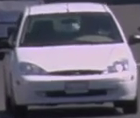

ID: 111 | Label: car | Max Conf: 0.91


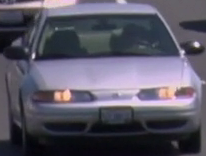

ID: 119 | Label: car | Max Conf: 0.92


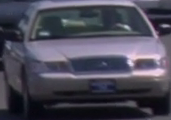

ID: 120 | Label: car | Max Conf: 0.93


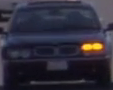

ID: 122 | Label: car | Max Conf: 0.88


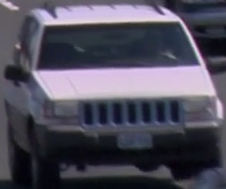

ID: 126 | Label: car | Max Conf: 0.81


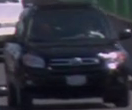

ID: 127 | Label: car | Max Conf: 0.90


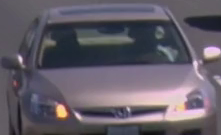

ID: 129 | Label: car | Max Conf: 0.87


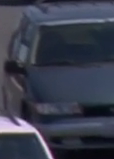

ID: 134 | Label: car | Max Conf: 0.91


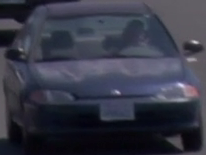

ID: 139 | Label: car | Max Conf: 0.79


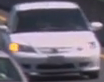

ID: 142 | Label: car | Max Conf: 0.91


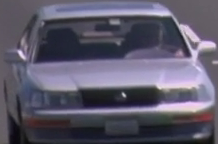

ID: 144 | Label: car | Max Conf: 0.88


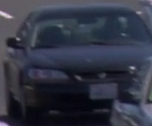

ID: 145 | Label: car | Max Conf: 0.89


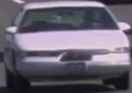

ID: 150 | Label: car | Max Conf: 0.84


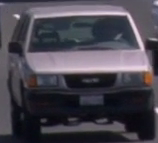

ID: 151 | Label: car | Max Conf: 0.88


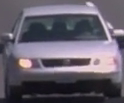

ID: 154 | Label: car | Max Conf: 0.91


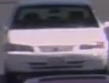

ID: 156 | Label: car | Max Conf: 0.88


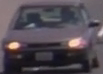

ID: 161 | Label: car | Max Conf: 0.87


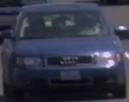

ID: 163 | Label: car | Max Conf: 0.81


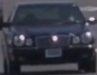

ID: 164 | Label: car | Max Conf: 0.72


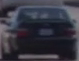

ID: 165 | Label: car | Max Conf: 0.71


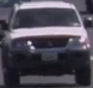

ID: 166 | Label: car | Max Conf: 0.89


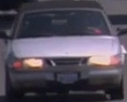

ID: 168 | Label: car | Max Conf: 0.82


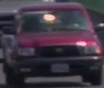

ID: 169 | Label: car | Max Conf: 0.85


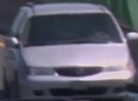

ID: 170 | Label: car | Max Conf: 0.77


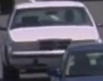

ID: 171 | Label: car | Max Conf: 0.86


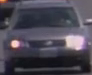

ID: 172 | Label: car | Max Conf: 0.66


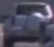

ID: 173 | Label: truck | Max Conf: 0.86


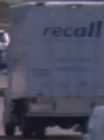

ID: 174 | Label: car | Max Conf: 0.80


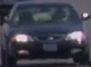

ID: 178 | Label: car | Max Conf: 0.82


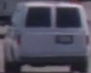

ID: 179 | Label: car | Max Conf: 0.60


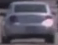

ID: 180 | Label: car | Max Conf: 0.80


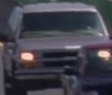

ID: 182 | Label: car | Max Conf: 0.59


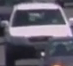

ID: 184 | Label: car | Max Conf: 0.77


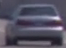

ID: 185 | Label: car | Max Conf: 0.56


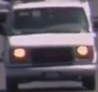

ID: 186 | Label: car | Max Conf: 0.84


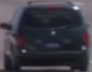

ID: 187 | Label: car | Max Conf: 0.77


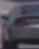

ID: 189 | Label: car | Max Conf: 0.64


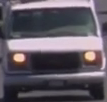

ID: 190 | Label: car | Max Conf: 0.53


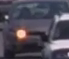

In [64]:
for carId, carObj in carsDict.items():
    if carObj.lastCrop is not None:
        print(f"ID: {carId} | Label: {carObj.label} | Max Conf: {carObj.maxConfidence:.2f}")
        display(Image.fromarray(carObj.lastCrop))